# 1. Setup and Data loading

In [1]:
#impoting required libraries for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading datasets
vendor_purchase_prices = pd.read_csv("Vendor_Purchase_Prices_Dec_2017.csv")
beginning_inventory = pd.read_csv("Beginning_Inventory_Dec_31_2016.csv")
ending_inventory = pd.read_csv("Ending_Inventory_Dec_31_2016.csv")
invoice_purchases = pd.read_csv("Invoice_Purchases_Dec_31_2016.csv")
purchases = pd.read_csv("Purchases_Dec_31_2016.csv")
sales = pd.read_csv("Sales_Dec_31_2016.csv")

In [3]:
#printing columns for all dataframes
print("Vendor purchases columns:")
print(vendor_purchase_prices.columns.tolist())

print("\n-----------------------------------")

print("\nbeginning_inventory columns:")
print(beginning_inventory.columns.tolist())

print("\n-----------------------------------")

print("\nending_inventory columns:")
print(ending_inventory.columns.tolist())

print("\n-----------------------------------")

print("\ninvoice_purchases columns:")
print(invoice_purchases.columns.tolist())

print("\n-----------------------------------")

print("\npurchases columns:")
print(purchases.columns.tolist())

print("\n-----------------------------------")

print("\nsales columns:")
print(sales.columns.tolist())

Vendor purchases columns:
['Brand', 'Description', 'Price', 'Size', 'Volume', 'Classification', 'PurchasePrice', 'VendorNumber', 'VendorName']

-----------------------------------

beginning_inventory columns:
['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'startDate']

-----------------------------------

ending_inventory columns:
['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'endDate']

-----------------------------------

invoice_purchases columns:
['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate', 'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval']

-----------------------------------

purchases columns:
['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber', 'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification']

-----------------------------------

sales columns:
['InventoryId', 'Store',

# 2. Datasets summary and potential relationship between them

| Dataset                 | Summary                                                                                            | Potential Relationship                                                                                                                |
| ----------------------- | -------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| **Vendor Purchases**    | Master list of products supplied by vendors, including purchase price, product attributes, and vendor details. | Linked to **Purchases** via `VendorNumber`, `Brand`, `Description`; linked to **Sales** and **Inventory** through product attributes. |
| **Beginning Inventory** | Opening inventory balance for each product at each store at the start of the period.                           | Linked to **Ending Inventory**, **Purchases**, and **Sales** via `InventoryId` or (`Store`, `Brand`, `Description`, `Size`).          |
| **Ending Inventory**    | Closing inventory balance for each product at each store at the end of the period.                             | Compared with **Beginning Inventory**, **Purchases**, and **Sales** for inventory movement analysis.                                  |
| **Invoice Purchases**   | Purchase order invoice records containing vendor payments, freight, and approval information.                  | Linked to **Purchases** using `VendorNumber` and `PONumber`; useful for procurement and payment analysis.                             |
| **Purchases**           | Detailed records of products purchased by stores from vendors, including quantities, cost, and purchase dates. | Central fact table connected to **Vendor Purchases**, **Invoice Purchases**, **Inventory**, and **Sales**.                            |
| **Sales**               | Product-level sales transactions showing quantity sold, revenue, selling price, taxes, and vendor information. | Linked to **Purchases** and **Inventory** via `InventoryId`; connected to **Vendor Purchases** using product/vendor information.      |


# 3. Data cleanig

In [4]:
#function to check for missing values
def data_cleaning(df, df_name):
    print(f"\nMissing values in {df_name}:")
    missing_values = df.isnull().sum()
    missing_values = missing_values[missing_values>0] #fetch columns with missing values
    if missing_values.empty:
        print("No missing value found")
    else:
        print(missing_values)

        
#datasets with name and dataframe
datasets = {
    'Vendor purchases prices' : vendor_purchase_prices,
    'Beginning inventory' : beginning_inventory,
    'Ending inventory' : ending_inventory,
    'Invoice purchase' : invoice_purchases,
    'Purchases' : purchases,
    'Sales' : sales
}


#loop for checking missing values for each dataframe
for df_name, df in datasets.items():
    data_cleaning(df, df_name)


Missing values in Vendor purchases prices:
Description    1
Size           1
Volume         1
dtype: int64

Missing values in Beginning inventory:
No missing value found

Missing values in Ending inventory:
City    1284
dtype: int64

Missing values in Invoice purchase:
Approval    5169
dtype: int64

Missing values in Purchases:
Size    3
dtype: int64

Missing values in Sales:
No missing value found


## we have total 1284 missing values in the city column. after doing analysis I got to know that only one store which is 46 has missing values in city column

In [5]:
#I will fetch the data where city is null
missing_city = ending_inventory[ending_inventory['City'].isnull()]

print("Groupped data by store to find missing values in city column:\n")
missing_city.groupby('Store').size().reset_index(name='Missing city count')



Groupped data by store to find missing values in city column:



,Store,Missing city count
0,46,1284


In [6]:
#look for unique values in approval column
distinct_values = invoice_purchases['Approval'].unique()
distinct_value_count = invoice_purchases['Approval'].value_counts(dropna=False)
print("Unique values in approval column:")
print(distinct_values)
print("Unique value count:")
print(distinct_value_count)

Unique values in approval column:
<StringArray>
[nan, 'Frank Delahunt']
Length: 2, dtype: str
Unique value count:
Approval
NaN               5169
Frank Delahunt     374
Name: count, dtype: int64


In [7]:
#Handling missing values

#vendor purchase
#dropping rows where 'Description', 'Size', 'Volume' are missing
vendor_purchase_prices.dropna(subset=['Description', 'Size', 'Volume'], inplace=True)

#ending inventory
#filling missing value for city column with 'unknown' 
ending_inventory['City'] = ending_inventory['City'].fillna('Unknown')

#Invoice purchases
#filling missing value for approval column with 'unknown' 
invoice_purchases['Approval'] = invoice_purchases['Approval'].fillna('Unknown')

#Purchases
#dropping rows where size is missing
purchases.dropna(subset=['Size'], inplace=True)

In [8]:
print("Missing values in all dataframes after handling: ")
for df_name, df in datasets.items():
    data_cleaning(df, df_name)

Missing values in all dataframes after handling: 

Missing values in Vendor purchases prices:
No missing value found

Missing values in Beginning inventory:
No missing value found

Missing values in Ending inventory:
No missing value found

Missing values in Invoice purchase:
No missing value found

Missing values in Purchases:
No missing value found

Missing values in Sales:
No missing value found


# 4. Consolidating dataframes

In [9]:
#Summarize the total purchases per item
total_purchases = purchases.groupby(['InventoryId','Store','Brand','Description','Size'])['Quantity'].sum().reset_index()
total_purchases.rename(columns={'Quantity':'TotalPurchased'}, inplace=True)

#Summarize the total sales per item
total_sales = sales.groupby(['InventoryId','Store','Brand','Description','Size'])['SalesQuantity'].sum().reset_index()
total_sales.rename(columns={'SalesQuantity':'TotalSold'}, inplace=True)

In [97]:
total_purchases

,InventoryId,Store,Brand,Description,Size,TotalPurchased
0,10_HORNSEY_1001,10,1001,Bailey's 50mL 4 Pack,50mL 4 Pk,120
1,10_HORNSEY_1003,10,1003,Crown Royal +2 Reusable Cups,750mL,227
2,10_HORNSEY_10030,10,10030,Pacifico Sur Pnt Nr Rsv,750mL,13
3,10_HORNSEY_1004,10,1004,Jim Beam w/2 Rocks Glasses,750mL,12
4,10_HORNSEY_10057,10,10057,Rocca delle Macie Sasyr Tscn,750mL,12
...,...,...,...,...,...,...
245970,9_BLACKPOOL_9388,9,9388,Hennessy Privilege VSOP,375mL,24
245971,9_BLACKPOOL_942,9,942,Glenmorangie Nectar D'Or,750mL,9
245972,9_BLACKPOOL_966,9,966,Patron Citronge Orange Liqu,750mL,84
245973,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,43


In [98]:
total_sales

,InventoryId,Store,Brand,Description,Size,TotalSold
0,10_HORNSEY_1000,10,1000,Goslings Dark'n Stormy VAP,750mL,1
1,10_HORNSEY_1001,10,1001,Bailey's 50mL 4 Pack,50mL 4 Pk,11
2,10_HORNSEY_10030,10,10030,Pacifico Sur Pnt Nr Rsv,750mL,2
3,10_HORNSEY_1005,10,1005,Maker's Mark Combo Pack,375mL 2 Pk,6
4,10_HORNSEY_10057,10,10057,Rocca delle Macie Sasyr Tscn,750mL,12
...,...,...,...,...,...,...
170126,9_BLACKPOOL_9358,9,9358,KAH Reposado Tequila,750mL,1
170127,9_BLACKPOOL_938,9,938,Jack Daniels Master Dist VAP,750mL,6
170128,9_BLACKPOOL_9388,9,9388,Hennessy Privilege VSOP,375mL,1
170129,9_BLACKPOOL_966,9,966,Patron Citronge Orange Liqu,750mL,3


In [10]:
#merging begininng and ending dataframe
inventory = pd.merge(beginning_inventory, ending_inventory,
                     on = ['InventoryId','Store','Brand','Description','Size'],
                     how = 'outer',
                     suffixes=['_beg', '_end'])

#merging total_purchases
inventory = pd.merge(inventory, total_purchases,
                    on = ['InventoryId','Store','Brand','Description','Size'],
                    how='left')

#merging total_sales
inventory = pd.merge(inventory, total_sales,
                    on = ['InventoryId','Store','Brand','Description','Size'],
                    how='left')

In [100]:
inventory

,InventoryId,Store,City_beg,Brand,Description,Size,onHand_beg,Price_beg,startDate,City_end,onHand_end,Price_end,endDate,TotalPurchased,TotalSold
0,10_HORNSEY_1000,10,HORNSEY,1000,Goslings Dark'n Stormy VAP,750mL,1.0,14.99,2016-01-01,NaN,NaN,NaN,NaN,NaN,1.0
1,10_HORNSEY_1001,10,HORNSEY,1001,Baileys 50mL 4 Pack,50mL 4 Pk,11.0,5.99,2016-01-01,HORNSEY,0.0,5.99,2016-12-31,NaN,NaN
2,10_HORNSEY_1003,10,NaN,1003,Crown Royal VAP Glass+Coastr,750mL,NaN,NaN,NaN,HORNSEY,73.0,22.99,2016-12-31,NaN,NaN
3,10_HORNSEY_1005,10,HORNSEY,1005,Maker's Mark Combo Pack,375mL 2 Pk,18.0,34.99,2016-01-01,NaN,NaN,NaN,NaN,NaN,6.0
4,10_HORNSEY_10058,10,HORNSEY,10058,F Coppola Dmd Ivry Cab Svgn,750mL,52.0,14.99,2016-01-01,HORNSEY,24.0,14.99,2016-12-31,173.0,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258688,9_BLACKPOOL_9388,9,BLACKPOOL,9388,Hennessy Privilege VSOP,375mL,7.0,23.99,2016-01-01,BLACKPOOL,4.0,23.99,2016-12-31,24.0,1.0
258689,9_BLACKPOOL_942,9,NaN,942,Glenmorangie Nectar D'Or,750mL,NaN,NaN,NaN,BLACKPOOL,2.0,61.99,2016-12-31,9.0,NaN
258690,9_BLACKPOOL_966,9,BLACKPOOL,966,Patron Citronge Orange Liqu,750mL,8.0,20.99,2016-01-01,BLACKPOOL,9.0,20.99,2016-12-31,84.0,3.0
258691,9_BLACKPOOL_984,9,BLACKPOOL,984,Patron XO Cafe Liqueur,750mL,23.0,25.99,2016-01-01,BLACKPOOL,5.0,25.99,2016-12-31,43.0,6.0


In [11]:
#filling nan with 0 for TotalPurchased and TotalSales
inventory['TotalPurchased'] = inventory['TotalPurchased'].fillna(0)
inventory['TotalSold'] = inventory['TotalSold'].fillna(0)

In [102]:
inventory.isnull().sum()

InventoryId           0
Store                 0
City_beg          52164
Brand                 0
Description           0
Size                  0
onHand_beg        52164
Price_beg         52164
startDate         52164
City_end          34204
onHand_end        34204
Price_end         34204
endDate           34204
TotalPurchased        0
TotalSold             0
dtype: int64

In [12]:
#Calculating total 'onHand' for the original beginning inventory
total_beg_inv_original = beginning_inventory['onHand'].sum()

#Calculating total 'onHand' for the merged beginning inventory
total_beg_inv_merged = inventory['onHand_beg'].sum()

#Calculating total 'onHand' for the original ending inventory
total_end_inv_original = ending_inventory['onHand'].sum()

#Calculating total 'onHand' for the merged ending inventory
total_end_inv_merged = inventory['onHand_end'].sum()

In [13]:
print(f"Total onhand for original beginning inventory: {total_beg_inv_original}")
print(f"Total onhand for merged beginning inventory: {total_beg_inv_merged}")
print(f"Total onhand for original ending inventory: {total_end_inv_original}")
print(f"Total onhand for merged ending inventory: {total_end_inv_merged}")

Total onhand for original beginning inventory: 4219275
Total onhand for merged beginning inventory: 4219275.0
Total onhand for original ending inventory: 4885776
Total onhand for merged ending inventory: 4885776.0


In [14]:
inventory['Expected_onHand_end'] = inventory['onHand_beg'] + inventory['TotalPurchased'] - inventory['TotalSold']

# 5. Exploratory Data Analysis

In [15]:
print(inventory.info())
print(inventory.describe())
print(inventory.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 258693 entries, 0 to 258692
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   InventoryId          258693 non-null  str    
 1   Store                258693 non-null  int64  
 2   City_beg             206529 non-null  str    
 3   Brand                258693 non-null  int64  
 4   Description          258693 non-null  str    
 5   Size                 258693 non-null  str    
 6   onHand_beg           206529 non-null  float64
 7   Price_beg            206529 non-null  float64
 8   startDate            206529 non-null  str    
 9   City_end             224489 non-null  str    
 10  onHand_end           224489 non-null  float64
 11  Price_end            224489 non-null  float64
 12  endDate              224489 non-null  str    
 13  TotalPurchased       258693 non-null  float64
 14  TotalSold            258693 non-null  float64
 15  Expected_onHand_end  206529 

In [16]:
#columns with Null values
columns_with_nulls = ['City_beg','onHand_beg','Price_beg','startDate','City_end','onHand_end','Price_end','endDate']

rows_with_nulls = inventory[inventory[columns_with_nulls].isnull().any(axis=1)]

rows_with_nulls.head(10)

,InventoryId,Store,City_beg,Brand,Description,Size,onHand_beg,Price_beg,startDate,City_end,onHand_end,Price_end,endDate,TotalPurchased,TotalSold,Expected_onHand_end
0,10_HORNSEY_1000,10,HORNSEY,1000,Goslings Dark'n Stormy VAP,750mL,1.0,14.99,2016-01-01,NaN,NaN,NaN,NaN,0.0,1.0,0.0
2,10_HORNSEY_1003,10,NaN,1003,Crown Royal VAP Glass+Coastr,750mL,NaN,NaN,NaN,HORNSEY,73.0,22.99,2016-12-31,0.0,0.0,NaN
3,10_HORNSEY_1005,10,HORNSEY,1005,Maker's Mark Combo Pack,375mL 2 Pk,18.0,34.99,2016-01-01,NaN,NaN,NaN,NaN,0.0,6.0,12.0
5,10_HORNSEY_1006,10,HORNSEY,1006,Jim Beam Candy Cane 4/50mLs,50mL 4 Pk,1.0,3.99,2016-01-01,NaN,NaN,NaN,NaN,0.0,1.0,0.0
6,10_HORNSEY_10062,10,NaN,10062,B de Beauchene CDR Rouge,750mL,NaN,NaN,NaN,HORNSEY,15.0,8.99,2016-12-31,0.0,0.0,NaN
7,10_HORNSEY_10062,10,HORNSEY,10062,Terroirs du Rhone,750mL,11.0,8.99,2016-01-01,NaN,NaN,NaN,NaN,11.0,6.0,16.0
8,10_HORNSEY_1009,10,HORNSEY,1009,Rebel Yell Variety Pack,750mL 3 Pk,3.0,49.99,2016-01-01,NaN,NaN,NaN,NaN,0.0,3.0,0.0
9,10_HORNSEY_1012,10,HORNSEY,1012,Courvoisier VSOP VAP,750mL,2.0,34.99,2016-01-01,NaN,NaN,NaN,NaN,0.0,2.0,0.0
10,10_HORNSEY_1013,10,HORNSEY,1013,Kahlua Pumpkin Spice Liqueur,750mL,5.0,18.99,2016-01-01,NaN,NaN,NaN,NaN,0.0,1.0,4.0
13,10_HORNSEY_1021,10,HORNSEY,1021,St Brendans Peppermint Bark,750mL,5.0,13.99,2016-01-01,NaN,NaN,NaN,NaN,0.0,0.0,5.0


In [17]:
#filter rows with non null values
rows_with_all_data = inventory.dropna()

rows_with_all_data.head()

,InventoryId,Store,City_beg,Brand,Description,Size,onHand_beg,Price_beg,startDate,City_end,onHand_end,Price_end,endDate,TotalPurchased,TotalSold,Expected_onHand_end
1,10_HORNSEY_1001,10,HORNSEY,1001,Baileys 50mL 4 Pack,50mL 4 Pk,11.0,5.99,2016-01-01,HORNSEY,0.0,5.99,2016-12-31,0.0,0.0,11.0
4,10_HORNSEY_10058,10,HORNSEY,10058,F Coppola Dmd Ivry Cab Svgn,750mL,52.0,14.99,2016-01-01,HORNSEY,24.0,14.99,2016-12-31,173.0,32.0,193.0
11,10_HORNSEY_10164,10,HORNSEY,10164,Andre Bourgogne Pnt Nr RSV,750mL,13.0,15.99,2016-01-01,HORNSEY,19.0,15.99,2016-12-31,12.0,0.0,25.0
12,10_HORNSEY_1019,10,HORNSEY,1019,Drambuie Glass Pack,750mL,0.0,26.99,2016-01-01,HORNSEY,11.0,26.99,2016-12-31,18.0,0.0,18.0
15,10_HORNSEY_10227,10,HORNSEY,10227,Due Torri Pnt Nr del Venezie,750mL,8.0,9.99,2016-01-01,HORNSEY,7.0,9.99,2016-12-31,12.0,0.0,20.0


In [18]:
matching_rows = inventory[inventory['onHand_end'] == inventory['Expected_onHand_end']]
matching_rows

,InventoryId,Store,City_beg,Brand,Description,Size,onHand_beg,Price_beg,startDate,City_end,onHand_end,Price_end,endDate,TotalPurchased,TotalSold,Expected_onHand_end
68,10_HORNSEY_10676,10,HORNSEY,10676,William Hill Est Cab Svgn RV,750mL,8.0,42.99,2016-01-01,HORNSEY,8.0,42.99,2016-12-31,0.0,0.0,8.0
93,10_HORNSEY_11080,10,HORNSEY,11080,G Vigouroux Pigmentum Malbec,750mL,21.0,9.99,2016-01-01,HORNSEY,21.0,8.99,2016-12-31,0.0,0.0,21.0
224,10_HORNSEY_1274,10,HORNSEY,1274,No. 14 Bourbon,750mL,0.0,44.99,2016-01-01,HORNSEY,0.0,44.99,2016-12-31,0.0,0.0,0.0
244,10_HORNSEY_13061,10,HORNSEY,13061,P Michael Les Pavots Est Brd,750mL,2.0,187.99,2016-01-01,HORNSEY,2.0,187.99,2016-12-31,0.0,0.0,2.0
498,10_HORNSEY_15871,10,HORNSEY,15871,Cyan Toro Zamora,750mL,9.0,15.99,2016-01-01,HORNSEY,9.0,15.99,2016-12-31,0.0,0.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257853,9_BLACKPOOL_45992,9,BLACKPOOL,45992,Casa Liliana Good Chard,750mL,0.0,10.99,2016-01-01,BLACKPOOL,0.0,10.99,2016-12-31,0.0,0.0,0.0
257863,9_BLACKPOOL_4625,9,BLACKPOOL,4625,Courvoisier XO Cognac,750mL,3.0,139.99,2016-01-01,BLACKPOOL,3.0,139.99,2016-12-31,0.0,0.0,3.0
258318,9_BLACKPOOL_6872,9,BLACKPOOL,6872,Marquis de Chasse Red Gines,750mL,0.0,9.99,2016-01-01,BLACKPOOL,0.0,11.99,2016-12-31,0.0,0.0,0.0
258341,9_BLACKPOOL_6986,9,BLACKPOOL,6986,Marquis de Chasse Ginestet,750mL,0.0,9.99,2016-01-01,BLACKPOOL,0.0,11.99,2016-12-31,0.0,0.0,0.0


# 6. Discrepancy Analysis

In [19]:
inventory['Discrepancy'] = inventory['Expected_onHand_end'] - inventory['onHand_end']

In [20]:
print(inventory['Discrepancy'].describe())

count    172325.000000
mean        152.488664
std         341.055875
min        -269.000000
25%          23.000000
50%          61.000000
75%         149.000000
max       12170.000000
Name: Discrepancy, dtype: float64


##### In below code I use the ending inventory price to value the discrepancy because it represents the latest available price. If that price is unavailable, I fall back to the beginning inventory price. Multiplying the discrepancy quantity by the selected price converts the inventory difference from units into its dollar value, making it easier to measure the financial impact.For example, if the discrepancy is 5 units and the price is $20, the discrepancy value is $100, meaning there is a $100 inventory difference.

In [21]:
inventory['Price_for_calculation'] = inventory['Price_end'].fillna(inventory['Price_beg'])
inventory['Discrepancy'] = pd.to_numeric(inventory['Discrepancy'], errors='coerce')
inventory['Discrepancy_value'] = inventory['Discrepancy']*inventory['Price_for_calculation']

In [22]:
#identify top 5 product with positive discrepancy value
top_positive_descrepancy = inventory[inventory['Discrepancy_value'] > 0].sort_values(by='Discrepancy_value', ascending=False)
positive_discrepancy = top_positive_descrepancy[['InventoryId','Description','Store','Brand','City_end','Discrepancy','Discrepancy_value']].head()

In [23]:
positive_discrepancy

,InventoryId,Description,Store,Brand,City_end,Discrepancy,Discrepancy_value
128888,50_MOUNTMEND_1233,Jack Daniels No 7 Black,50,1233,MOUNTMEND,8428.0,294895.72
234469,76_DONCASTER_3405,Tito's Handmade Vodka,76,3405,DONCASTER,9542.0,276622.58
135694,50_MOUNTMEND_8068,Absolut 80 Proof,50,8068,MOUNTMEND,9285.0,218104.65
78245,34_PITMERDEN_3545,Ketel One Vodka,34,3545,PITMERDEN,7119.0,213498.81
234601,76_DONCASTER_3545,Ketel One Vodka,76,3545,DONCASTER,7100.0,212929.00


In [24]:
#identify top 5 product with negative discrepancy value
top_negative_discrepancy = inventory[inventory['Discrepancy_value'] < 0].sort_values(by='Discrepancy_value')
negative_discrepancy = top_negative_discrepancy[['InventoryId','Description','Store','Brand','City_end','Discrepancy','Discrepancy_value']].head()

In [25]:
negative_discrepancy

,InventoryId,Description,Store,Brand,City_end,Discrepancy,Discrepancy_value
191062,67_EANVERNESS_35464,Stags Leap WC Artemis Cab,67,35464,EANVERNESS,-125.0,-6123.75
184685,66_EANVERNESS_35464,Stags Leap WC Artemis Cab,66,35464,EANVERNESS,-90.0,-4409.10
130958,50_MOUNTMEND_2209,Pendleton 1910 Rye,50,2209,MOUNTMEND,-222.0,-3993.78
225996,74_PAENTMARWY_35464,Stags Leap WC Artemis Cab,74,35464,PAENTMARWY,-72.0,-3527.28
79079,34_PITMERDEN_4225,Goslings Black Seal Rum 80,34,4225,PITMERDEN,-128.0,-3326.72


#### Our discrepancy analysis has provided valuable insights into inventory accuracy and potential operational inefficiencies. For the top 5 products with a positive discrepancy, where actual inventory is less than expected, it's crucial to investigate discrepancies that may indicate unrecorded sales, stock losses, or other issues affecting inventory accuracy. Immediate actions should include reviewing sales recording practices, assessing theft or loss, and evaluating demand forecasting accuracy. Conversely, the top 5 products with a negative discrepancy, where actual inventory exceeds expectations, suggest potential overstocking or underreporting of sales. For these items, we recommend analyzing purchasing practices, reassessing demand forecasting, and improving inventory tracking systems. By addressing these discrepancies, the company can improve inventory accuracy, enhance financial reporting, and optimize stock levels, leading to better operational efficiency and customer satisfaction.

# 7. Recommended Inventory level

In [26]:
#calculate total sales volume for each product
sale_volume = inventory.groupby(['InventoryId', 'Description'])['TotalSold'].sum().reset_index(name='SaleVolume')

top_20_critical_products = sale_volume.sort_values(by='SaleVolume',ascending=False).head(20)

print(top_20_critical_products)

                InventoryId                   Description  SaleVolume
30568   1_HARDERSFIELD_8111             Smirnoff 80 Proof      1142.0
4201        10_HORNSEY_8111             Smirnoff 80 Proof      1104.0
79102     34_PITMERDEN_4261        Capt Morgan Spiced Rum      1055.0
142183      53_HILLFAR_8111             Smirnoff 80 Proof       939.0
3050        10_HORNSEY_4157    Smirnoff Green Apple Vodka       927.0
797         10_HORNSEY_1892                    Yukon Jack       921.0
53452     27_MOUNTMEND_8111             Smirnoff 80 Proof       909.0
3712        10_HORNSEY_5491                   Rumpleminze       905.0
11533      14_BROMWICH_1892                    Yukon Jack       854.0
12981      14_BROMWICH_4261        Capt Morgan Spiced Rum       850.0
78218     34_PITMERDEN_3545               Ketel One Vodka       843.0
3154        10_HORNSEY_4261        Capt Morgan Spiced Rum       836.0
2580        10_HORNSEY_3606      Smirnoff Raspberry Vodka       821.0
80384     34_PITMERD

In [31]:
top_20_inventory_ids = top_20_critical_products[['InventoryId']]

In [32]:
top_20_inventory_ids = top_20_inventory_ids['InventoryId'].tolist()
top_20_inventory_ids

['1_HARDERSFIELD_8111',
 '10_HORNSEY_8111',
 '34_PITMERDEN_4261',
 '53_HILLFAR_8111',
 '10_HORNSEY_4157',
 '10_HORNSEY_1892',
 '27_MOUNTMEND_8111',
 '10_HORNSEY_5491',
 '14_BROMWICH_1892',
 '14_BROMWICH_4261',
 '34_PITMERDEN_3545',
 '10_HORNSEY_4261',
 '10_HORNSEY_3606',
 '34_PITMERDEN_8111',
 '77_TAMWORTH_5111',
 '15_WANBORNE_8068',
 '27_MOUNTMEND_1892',
 '10_HORNSEY_8053',
 '1_HARDERSFIELD_3609',
 '10_HORNSEY_4135']

In [33]:
#converting POdate and ReceivingDate into datetime objects
purchases['PODate'] = pd.to_datetime(purchases['PODate'])
purchases['ReceivingDate'] = pd.to_datetime(purchases['ReceivingDate'])

#convert SalesDate into datetime
sales['SalesDate'] = pd.to_datetime(sales['SalesDate'])

In [34]:
#calculate the total days in dataset
total_days = (sales['SalesDate'].max() - sales['SalesDate'].min()).days

#calculate the avg daily sale for each product
avg_daily_sale = sales[sales['InventoryId'].isin(top_20_inventory_ids)].groupby('InventoryId')['SalesQuantity'].sum()/total_days

print(f"Average daily sale for top 20 products: {avg_daily_sale}")

Average daily sale for top 20 products: InventoryId
10_HORNSEY_1892        15.610169
10_HORNSEY_3606        13.915254
10_HORNSEY_4135        12.932203
10_HORNSEY_4157        15.711864
10_HORNSEY_4261        14.169492
10_HORNSEY_5491        15.338983
10_HORNSEY_8053        13.288136
10_HORNSEY_8111        18.711864
14_BROMWICH_1892       14.474576
14_BROMWICH_4261       14.406780
15_WANBORNE_8068       13.728814
1_HARDERSFIELD_3609    13.169492
1_HARDERSFIELD_8111    19.355932
27_MOUNTMEND_1892      13.491525
27_MOUNTMEND_8111      15.406780
34_PITMERDEN_3545      14.288136
34_PITMERDEN_4261      17.881356
34_PITMERDEN_8111      13.762712
53_HILLFAR_8111        15.915254
77_TAMWORTH_5111       13.745763
Name: SalesQuantity, dtype: float64


In [36]:
#calculating delivery days
purchases['delivery_days'] = (purchases['ReceivingDate'] - purchases['PODate']).dt.days

#calculating avg delivery days for top_20 products
avg_delivery_days = purchases[purchases['InventoryId'].isin(top_20_inventory_ids)].groupby('InventoryId')['delivery_days'].mean()

print(f"Avg delivery time for top 20 products: {avg_delivery_days}")

Avg delivery time for top 20 products: InventoryId
10_HORNSEY_1892        8.105263
10_HORNSEY_3606        8.258621
10_HORNSEY_4135        7.900000
10_HORNSEY_4157        7.963636
10_HORNSEY_4261        7.676190
10_HORNSEY_5491        7.939394
10_HORNSEY_8053        8.152778
10_HORNSEY_8111        7.961538
14_BROMWICH_1892       6.492063
14_BROMWICH_4261       6.612903
15_WANBORNE_8068       7.339623
1_HARDERSFIELD_3609    7.869565
1_HARDERSFIELD_8111    8.317460
27_MOUNTMEND_1892      7.658228
27_MOUNTMEND_8111      7.597938
34_PITMERDEN_3545      6.971154
34_PITMERDEN_4261      6.990909
34_PITMERDEN_8111      7.275510
53_HILLFAR_8111        7.656863
77_TAMWORTH_5111       7.629213
Name: delivery_days, dtype: float64


#### The Reorder Point tells us when we should place a new order to avoid running out of stock.

In [39]:
# Initialize a list to store the results
rows = []

# Loop through each top 20 InventoryId
for inventory_id in top_20_inventory_ids:
    # Retrieve the average daily sales and lead time for the product
    product_avg_daly_sale = avg_daily_sale.get(inventory_id, 0)
    product_avg_delivery_days = avg_delivery_days.get(inventory_id, 0)
    
    # Calculate the Reorder Point (ROP) without safety stock
    product_rop = product_avg_daly_sale * product_avg_delivery_days
    
    # Append the results to the list
    rows.append({
        "InventoryId": inventory_id,
        "Reorder Point": product_rop
    })

#loading result to dataframe
recommended_stock_levels = pd.DataFrame(rows)

# Print the recommended stock levels for the top 20 products
print("Recommended Stock Levels for Top 20 Products:")
print(recommended_stock_levels)

Recommended Stock Levels for Top 20 Products:
            InventoryId  Reorder Point
0   1_HARDERSFIELD_8111     160.992198
1       10_HORNSEY_8111     148.975228
2     34_PITMERDEN_4261     125.006934
3       53_HILLFAR_8111     121.860917
4       10_HORNSEY_4157     125.123575
5       10_HORNSEY_1892     126.524532
6     27_MOUNTMEND_8111     117.059759
7       10_HORNSEY_5491     121.782229
8      14_BROMWICH_1892      93.969868
9      14_BROMWICH_4261      95.270640
10    34_PITMERDEN_3545      99.604791
11      10_HORNSEY_4261     108.767716
12      10_HORNSEY_3606     114.920807
13    34_PITMERDEN_8111     100.130751
14     77_TAMWORTH_5111     104.869358
15     15_WANBORNE_8068     100.764311
16    27_MOUNTMEND_1892     103.321176
17      10_HORNSEY_8053     108.335217
18  1_HARDERSFIELD_3609     103.638172
19      10_HORNSEY_4135     102.164407


In [40]:
# Merge the recommended Reorder Points with the actual ending inventory from the inventory DataFrame
comparison = recommended_stock_levels.merge(inventory[['InventoryId', 'onHand_end']], on='InventoryId', how='left')

# Calculate the difference between the Reorder Point and the actual ending inventory
comparison['Difference'] = comparison['onHand_end'] - comparison['Reorder Point']

# Display the results
print("Comparison of Reorder Point with Actual Ending Inventory:")
print(comparison[['InventoryId', 'Reorder Point', 'onHand_end', 'Difference']])

Comparison of Reorder Point with Actual Ending Inventory:
            InventoryId  Reorder Point  onHand_end  Difference
0   1_HARDERSFIELD_8111     160.992198       417.0  256.007802
1       10_HORNSEY_8111     148.975228       424.0  275.024772
2     34_PITMERDEN_4261     125.006934       612.0  486.993066
3       53_HILLFAR_8111     121.860917      1066.0  944.139083
4       10_HORNSEY_4157     125.123575       212.0   86.876425
5       10_HORNSEY_1892     126.524532       110.0  -16.524532
6     27_MOUNTMEND_8111     117.059759       269.0  151.940241
7       10_HORNSEY_5491     121.782229       296.0  174.217771
8      14_BROMWICH_1892      93.969868       283.0  189.030132
9      14_BROMWICH_4261      95.270640        71.0  -24.270640
10    34_PITMERDEN_3545      99.604791       853.0  753.395209
11      10_HORNSEY_4261     108.767716       223.0  114.232284
12      10_HORNSEY_3606     114.920807       141.0   26.079193
13    34_PITMERDEN_8111     100.130751       133.0   32.8692

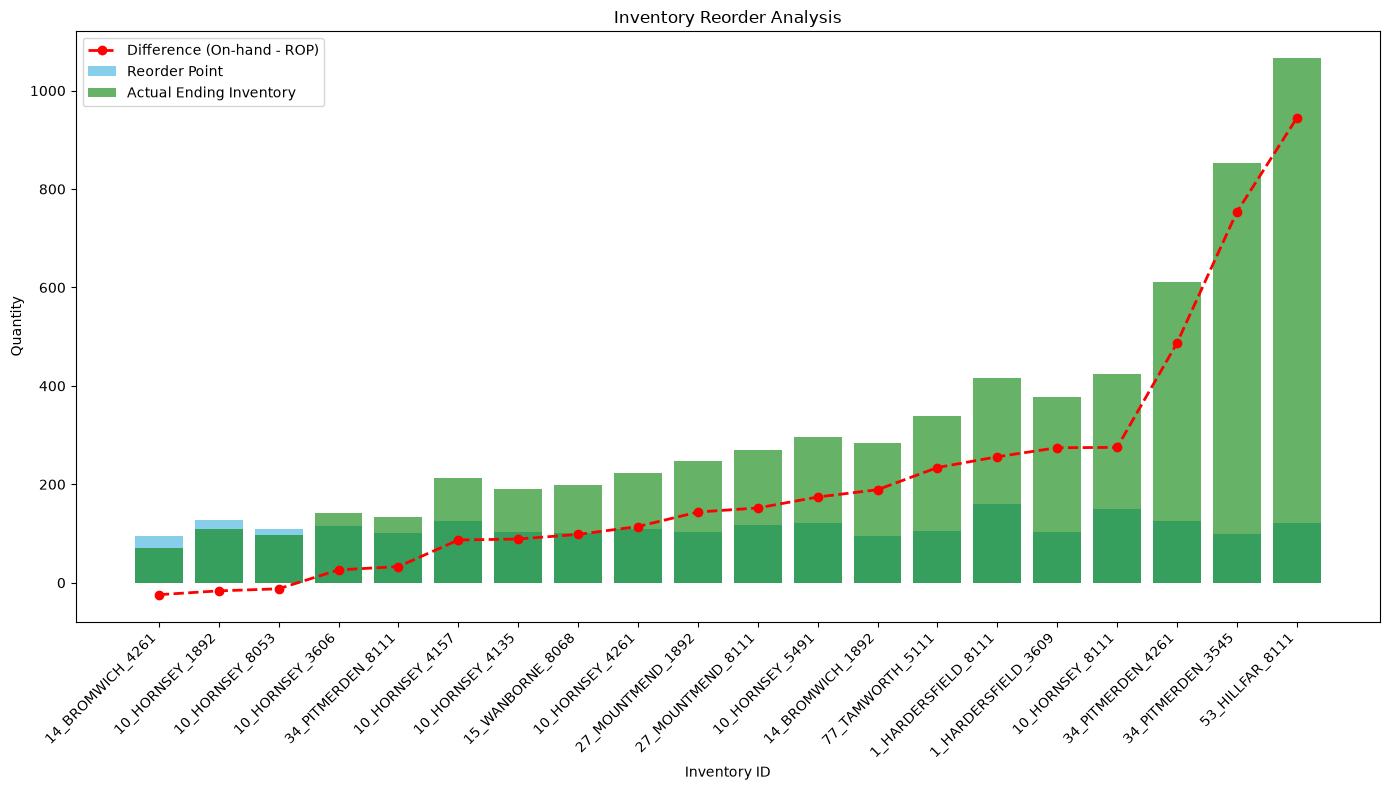

In [41]:
# Assuming 'comparison' is the DataFrame from the previous step
# Sort the values based on the difference for better visualization
comparison_sorted = comparison.sort_values('Difference')

# Plotting
plt.figure(figsize=(14, 8))

# Reorder Point
plt.bar(comparison_sorted['InventoryId'], comparison_sorted['Reorder Point'], color='skyblue', label='Reorder Point')

# Actual Ending Inventory
plt.bar(comparison_sorted['InventoryId'], comparison_sorted['onHand_end'], color='green', alpha=0.6, label='Actual Ending Inventory')

# Overlay Difference as a line for clarity
plt.plot(comparison_sorted['InventoryId'], comparison_sorted['Difference'], color='red', marker='o', linestyle='dashed', linewidth=2, markersize=6, label='Difference (On-hand - ROP)')

# Labels and Title
plt.xlabel('Inventory ID')
plt.ylabel('Quantity')
plt.title('Inventory Reorder Analysis')
plt.xticks(rotation=45, ha='right')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()
